# 02 — A/B Hypothesis Testing
**ACIS Insurance Dataset**

Statistical tests to validate or reject four key risk hypotheses that will form the evidence base for ACIS's new segmentation and pricing strategy.

---

### Risk KPIs
| KPI | Definition | Applicable test |
|-----|-----------|----------------|
| **Claim Frequency** | Proportion of policies with ≥ 1 claim | Chi-squared |
| **Claim Severity** | Mean claim amount given a claim occurred | Welch t-test / Kruskal-Wallis |
| **Margin** | TotalPremium − TotalClaims | Welch t-test |

### Null Hypotheses
| # | H₀ |
|---|-----|
| H1 | There are no risk differences **across provinces** |
| H2 | There are no risk differences **between zip codes** |
| H3 | There is no significant **margin difference between zip codes** |
| H4 | There is no significant risk difference **between Women and Men** |

*Decision rule: reject H₀ when p-value < 0.05.*

In [17]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path(".").resolve().parent))

from src.data_loader import load_data
from src.hypothesis_tests import (
    build_results_table,
    compute_claim_frequency,
    compute_claim_severity,
    compute_margin,
    select_comparable_zipcodes,
    test_gender_risk,
    test_province_risk,
    test_zipcode_margin,
    test_zipcode_risk,
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

print("Libraries loaded.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded.


---
## 1. Load Data

In [18]:
CLEAN_PATH = Path(".").resolve().parent / "data" / "insurance_data_cleaned.txt"

if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH, sep="|", low_memory=False,
                     na_values=["", " ", "NA", "N/A", "nan", "NaN"])
    df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"], errors="coerce")
    df["Margin"] = df["TotalPremium"] - df["TotalClaims"]
    print(f"Loaded cleaned data: {df.shape[0]:,} rows × {df.shape[1]} columns")
else:
    df = load_data()
    print(f"Loaded raw data: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\nClaim rate : {(df['TotalClaims'] > 0).mean():.4%}")
print(f"Provinces  : {df['Province'].nunique()}")
print(f"Postal codes: {df['PostalCode'].nunique()}")
print(f"Gender breakdown:\n{df['Gender'].value_counts()}")

Loaded raw data: 1,000,098 rows × 54 columns

Claim rate : 0.2788%
Provinces  : 9
Postal codes: 888
Gender breakdown:
Gender
Not specified    940990
Male              42817
Female             6755
Name: count, dtype: int64


---
## 2. H1 — Risk Differences Across Provinces

**H₀:** There are no risk differences across provinces.  
**KPIs:** Claim Frequency (chi-squared, all 9 provinces) + Claim Severity (Kruskal-Wallis)

In [19]:
province_results = test_province_risk(df)

# --- Claim Frequency results ---
fr = province_results["claim_frequency_test"]
print("=== Claim Frequency across Provinces ===")
print(f"  Test    : {fr['test']}")
print(f"  χ²      : {fr['chi2']:.4f}")
print(f"  p-value : {fr['p_value']:.2e}")
print(f"  Decision: {fr['decision']}\n")
print("Claim frequency by province:")
display(fr["claim_frequency_by_group"].rename("Claim Frequency").to_frame())

# --- Claim Severity results ---
sr = province_results["claim_severity_test"]
print("\n=== Claim Severity across Provinces ===")
print(f"  Test    : {sr['test']}")
print(f"  H-stat  : {sr['h_stat']:.4f}")
print(f"  p-value : {sr['p_value']:.2e}")
print(f"  Decision: {sr['decision']}\n")
print("Mean claim severity by province (claimants only):")
display(
    pd.Series(sr["mean_by_group"], name="Mean Claim Severity (ZAR)")
    .sort_values(ascending=False)
    .to_frame()
)

=== Claim Frequency across Provinces ===
  Test    : chi-squared (multi-group)
  χ²      : 104.1909
  p-value : 5.93e-19
  Decision: Reject H₀

Claim frequency by province:


,Claim Frequency
Province,
Gauteng,0.0034
KwaZulu-Natal,0.0028
Limpopo,0.0027
North West,0.0024
Mpumalanga,0.0024
Western Cape,0.0022
Eastern Cape,0.0016
Free State,0.0014
Northern Cape,0.0013



=== Claim Severity across Provinces ===
  Test    : Kruskal-Wallis
  H-stat  : 106.0927
  p-value : 2.41e-19
  Decision: Reject H₀

Mean claim severity by province (claimants only):


,Mean Claim Severity (ZAR)
Free State,32265.6611
KwaZulu-Natal,29609.4875
Western Cape,28095.8499
Eastern Cape,27128.5333
Gauteng,22243.8784
North West,16963.4670
Mpumalanga,15979.5534
Limpopo,15171.2942
Northern Cape,11186.3136


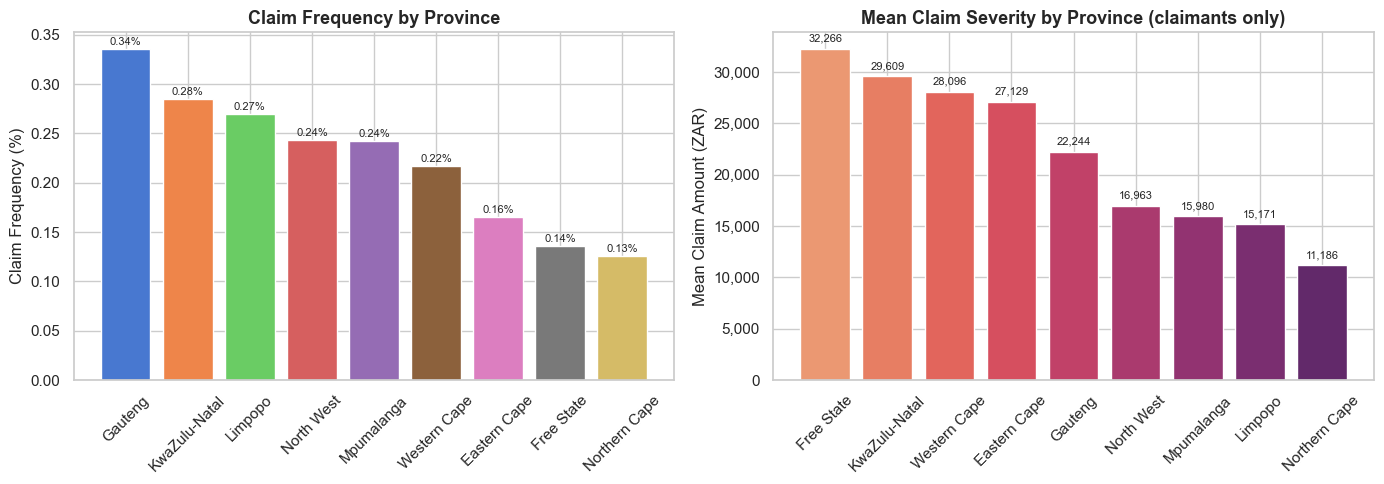

In [20]:
# Visualise claim frequency by province
freq_series = fr["claim_frequency_by_group"].sort_values(ascending=False)
sev_series  = pd.Series(sr["mean_by_group"]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Claim Frequency
bars = axes[0].bar(freq_series.index, freq_series.values * 100,
                   color=sns.color_palette("muted", len(freq_series)))
axes[0].set_title("Claim Frequency by Province", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Claim Frequency (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
for bar, val in zip(bars, freq_series.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f"{val*100:.2f}%", ha="center", va="bottom", fontsize=8)

# Right — Mean Claim Severity
bars2 = axes[1].bar(sev_series.index, sev_series.values,
                    color=sns.color_palette("flare", len(sev_series)))
axes[1].set_title("Mean Claim Severity by Province (claimants only)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Mean Claim Amount (ZAR)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, val in zip(bars2, sev_series.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f"{val:,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/h1_province_risk.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 3. H2 — Risk Differences Between Zip Codes

**H₀:** There are no risk differences between zip codes.  
**KPIs:** Claim Frequency (chi-squared) + Claim Severity (Welch t-test)  

Two zip codes are selected from the top-20 by volume whose VehicleType and CoverCategory distributions are most similar, so any difference observed can be attributed to the zip code itself.

In [21]:
# Identify the two most comparable zip codes
zip_a, zip_b = select_comparable_zipcodes(df, top_n=20)
print(f"Selected zip codes: {zip_a} (n={len(df[df['PostalCode']==zip_a]):,}) "
      f"vs {zip_b} (n={len(df[df['PostalCode']==zip_b]):,})")

# Profile comparison
for feat in ("VehicleType", "CoverCategory", "Province"):
    print(f"\n--- {feat} distribution ---")
    t = (df[df["PostalCode"].isin([zip_a, zip_b])]
         .groupby(["PostalCode", feat])
         .size()
         .unstack(fill_value=0)
         .apply(lambda x: x / x.sum(), axis=1)
         .T)
    display(t.map(lambda v: f"{v:.2%}"))

Selected zip codes: 7750 (n=9,408) vs 400 (n=6,692)

--- VehicleType distribution ---


PostalCode,400,7750
VehicleType,,
Medium Commercial,13.28%,6.11%
Passenger Vehicle,86.72%,93.89%



--- CoverCategory distribution ---


PostalCode,400,7750
CoverCategory,,
Accidental Death,2.99%,3.21%
Asset Value Preserver,0.00%,0.09%
Basic Excess Waiver,7.61%,8.40%
Basic Excess Waiver (2015),0.61%,0.21%
Cleaning and Removal of Accident Debris,9.97%,10.16%
Credit Protection,0.34%,1.90%
Deposit Cover,0.00%,0.32%
Emergency Charges,9.97%,10.16%
Income Protector,8.10%,3.88%



--- Province distribution ---


PostalCode,400,7750
Province,,
North West,100.00%,0.00%
Western Cape,0.00%,100.00%


In [22]:
zipcode_risk_results = test_zipcode_risk(df, zip_a, zip_b)

fr = zipcode_risk_results["claim_frequency_test"]
sr = zipcode_risk_results["claim_severity_test"]

print(f"=== Claim Frequency: PostalCode {zip_a} vs {zip_b} ===")
print(f"  Test          : {fr['test']}")
print(f"  χ²            : {fr['chi2']:.4f}")
print(f"  p-value       : {fr['p_value']:.2e}")
print(f"  Claim freq {zip_a}: {fr['claim_freq_a']:.4%}")
print(f"  Claim freq {zip_b}: {fr['claim_freq_b']:.4%}")
print(f"  Decision      : {fr['decision']}\n")

print(f"=== Claim Severity: PostalCode {zip_a} vs {zip_b} ===")
print(f"  Test          : {sr.get('test', 'N/A')}")
if "t_stat" in sr:
    print(f"  t-stat        : {sr['t_stat']:.4f}")
print(f"  p-value       : {sr.get('p_value', 'N/A'):.2e}" if isinstance(sr.get("p_value"), float) and not np.isnan(sr.get("p_value", np.nan)) else f"  p-value       : {sr.get('p_value', 'N/A')}")
for k, v in sr.items():
    if k.startswith("mean_"):
        print(f"  {k:<16}: ZAR {v:,.2f}")
print(f"  Decision      : {sr.get('decision', 'N/A')}")

=== Claim Frequency: PostalCode 7750 vs 400 ===
  Test          : chi-squared
  χ²            : 13.2722
  p-value       : 2.69e-04
  Claim freq 7750: 0.1807%
  Claim freq 400: 0.5081%
  Decision      : Reject H₀

=== Claim Severity: PostalCode 7750 vs 400 ===
  Test          : Welch t-test
  t-stat        : 1.6046
  p-value       : 1.25e-01
  mean_7750       : ZAR 21,929.24
  mean_400        : ZAR 7,133.12
  Decision      : Fail to Reject H₀


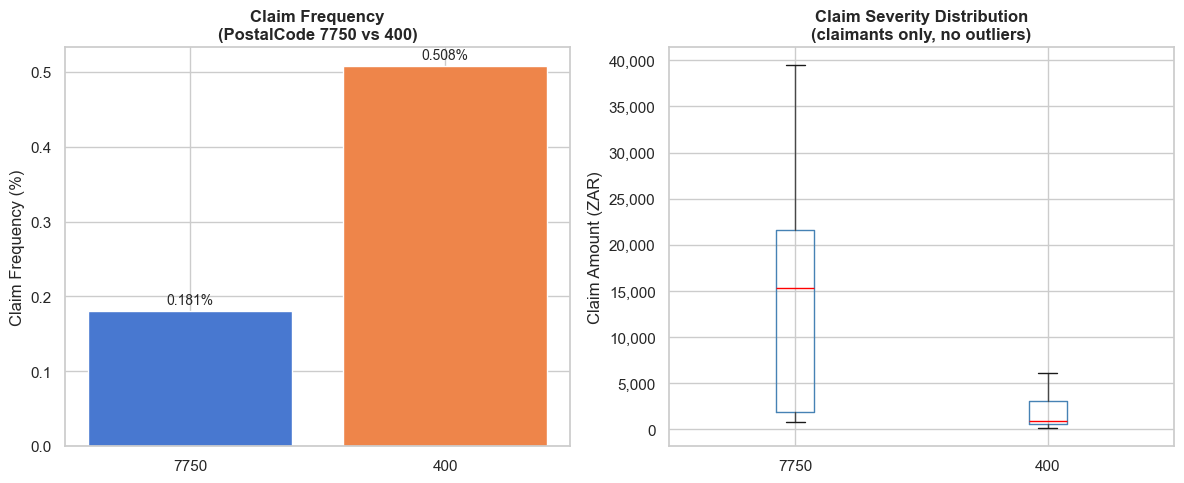

In [23]:
# Visualise claim frequency and severity for the two zip codes
grp_a = df[df["PostalCode"] == zip_a]
grp_b = df[df["PostalCode"] == zip_b]

freq_vals  = [compute_claim_frequency(grp_a).mean() * 100,
              compute_claim_frequency(grp_b).mean() * 100]
sev_a_vals = compute_claim_severity(grp_a).dropna()
sev_b_vals = compute_claim_severity(grp_b).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left – Claim Frequency bar
axes[0].bar([str(zip_a), str(zip_b)], freq_vals,
            color=sns.color_palette("muted", 2))
axes[0].set_title(f"Claim Frequency\n(PostalCode {zip_a} vs {zip_b})",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Claim Frequency (%)")
for i, v in enumerate(freq_vals):
    axes[0].text(i, v + 0.005, f"{v:.3f}%", ha="center", va="bottom", fontsize=10)

# Right – Claim Severity distribution (box)
data_sev = pd.DataFrame({
    str(zip_a): pd.Series(sev_a_vals.values),
    str(zip_b): pd.Series(sev_b_vals.values),
})
data_sev.boxplot(ax=axes[1], showfliers=False,
                 boxprops=dict(color="steelblue"),
                 medianprops=dict(color="red"))
axes[1].set_title(f"Claim Severity Distribution\n(claimants only, no outliers)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Claim Amount (ZAR)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("../reports/figures/h2_zipcode_risk.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 4. H3 — Margin Difference Between Zip Codes

**H₀:** There is no significant margin (profit) difference between zip codes.  
**KPI:** Margin = TotalPremium − TotalClaims (Welch t-test)

In [24]:
zipcode_margin_results = test_zipcode_margin(df, zip_a, zip_b)

zm = zipcode_margin_results
print(f"=== Margin Test: PostalCode {zip_a} vs {zip_b} ===")
print(f"  Test     : {zm['test']}")
print(f"  t-stat   : {zm['t_stat']:.4f}")
print(f"  p-value  : {zm['p_value']:.2e}")
for k, v in zm.items():
    if k.startswith("mean_"):
        label = k.replace("mean_", "Mean margin ")
        print(f"  {label:<25}: ZAR {v:,.4f}")
print(f"  Diff (B − A): ZAR {zm['diff']:,.4f}")
print(f"  Decision : {zm['decision']}")

=== Margin Test: PostalCode 7750 vs 400 ===
  Test     : Welch t-test
  t-stat   : -0.8339
  p-value  : 4.04e-01
  Mean margin 7750         : ZAR 19.4404
  Mean margin 400          : ZAR 38.8126
  Diff (B − A): ZAR 19.3722
  Decision : Fail to Reject H₀


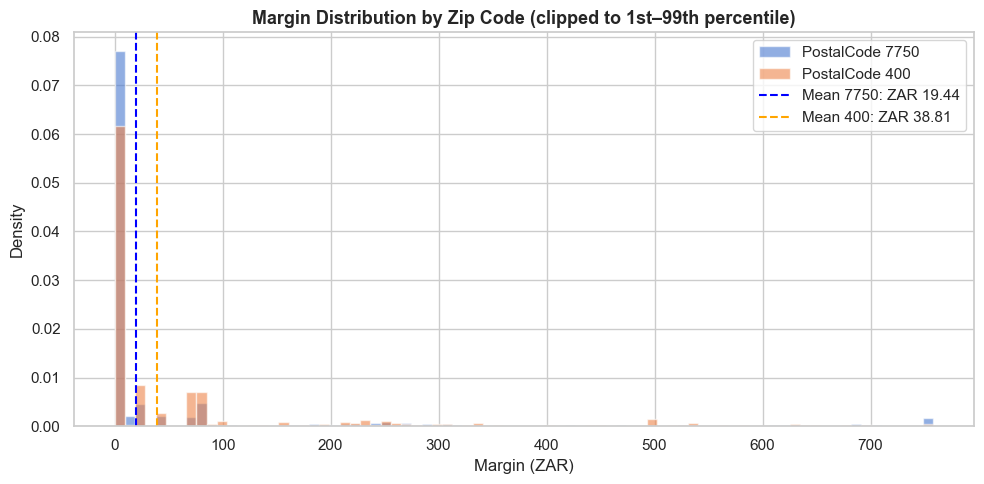

In [25]:
# Visualise margin distributions
margin_a = compute_margin(df[df["PostalCode"] == zip_a]).dropna()
margin_b = compute_margin(df[df["PostalCode"] == zip_b]).dropna()

# Clip extreme outliers for visualisation only
p01, p99 = np.percentile(pd.concat([margin_a, margin_b]), [1, 99])
ma_clip = margin_a.clip(p01, p99)
mb_clip = margin_b.clip(p01, p99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ma_clip, bins=80, alpha=0.6, label=f"PostalCode {zip_a}", density=True)
ax.hist(mb_clip, bins=80, alpha=0.6, label=f"PostalCode {zip_b}", density=True)
ax.axvline(margin_a.mean(), color="blue", linestyle="--",
           label=f"Mean {zip_a}: ZAR {margin_a.mean():,.2f}")
ax.axvline(margin_b.mean(), color="orange", linestyle="--",
           label=f"Mean {zip_b}: ZAR {margin_b.mean():,.2f}")
ax.set_title("Margin Distribution by Zip Code (clipped to 1st–99th percentile)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Margin (ZAR)")
ax.set_ylabel("Density")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("../reports/figures/h3_zipcode_margin.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. H4 — Risk Difference Between Women and Men

**H₀:** There is no significant risk difference between Women and Men.  
**KPIs:** Claim Frequency (chi-squared) + Claim Severity (Welch t-test)  
*Rows with Gender = "Not specified" are excluded from this test.*

In [26]:
gender_results = test_gender_risk(df)

fr = gender_results["claim_frequency_test"]
sr = gender_results["claim_severity_test"]

print("=== Gender Sample Sizes ===")
print(f"  Female : {gender_results['n_female']:,} policies")
print(f"  Male   : {gender_results['n_male']:,} policies")

print(f"\n=== Claim Frequency (Female vs Male) ===")
print(f"  Test          : {fr['test']}")
print(f"  χ²            : {fr['chi2']:.4f}")
print(f"  p-value       : {fr['p_value']:.2e}")
print(f"  Claim freq Female: {fr['claim_freq_a']:.4%}")
print(f"  Claim freq Male  : {fr['claim_freq_b']:.4%}")
print(f"  Decision      : {fr['decision']}")

print(f"\n=== Claim Severity (Female vs Male) ===")
print(f"  Test     : {sr.get('test', 'N/A')}")
if "t_stat" in sr:
    print(f"  t-stat   : {sr['t_stat']:.4f}")
    print(f"  p-value  : {sr['p_value']:.2e}")
    for k, v in sr.items():
        if k.startswith("mean_"):
            print(f"  {k:<18}: ZAR {v:,.2f}")
print(f"  Decision : {sr.get('decision', 'N/A')}")

=== Gender Sample Sizes ===
  Female : 6,755 policies
  Male   : 42,817 policies

=== Claim Frequency (Female vs Male) ===
  Test          : chi-squared
  χ²            : 0.0405
  p-value       : 8.40e-01
  Claim freq Female: 0.2073%
  Claim freq Male  : 0.2195%
  Decision      : Fail to Reject H₀

=== Claim Severity (Female vs Male) ===
  Test     : Welch t-test
  t-stat   : 0.5790
  p-value  : 5.68e-01
  mean_Female       : ZAR 17,874.72
  mean_Male         : ZAR 14,858.55
  Decision : Fail to Reject H₀


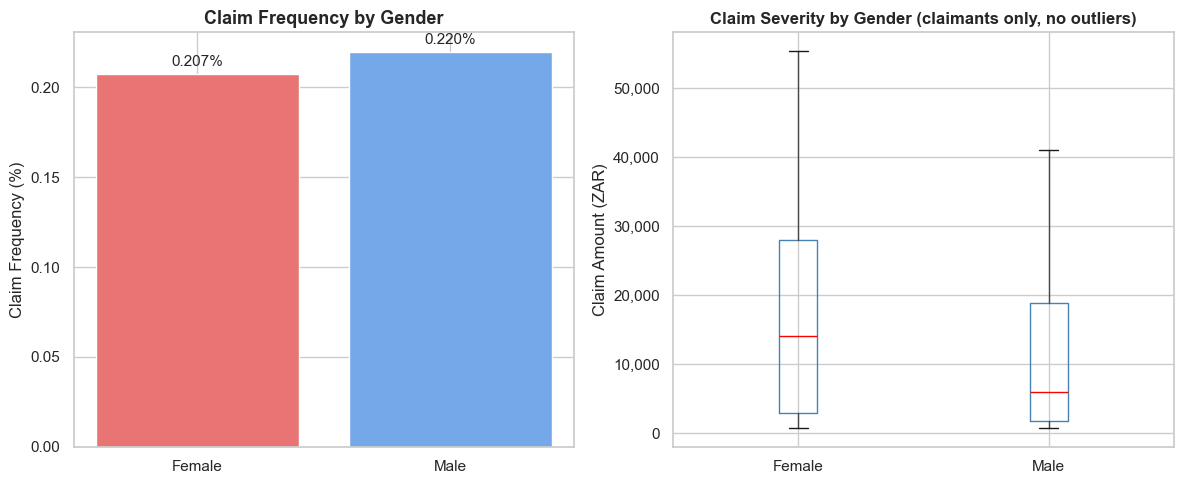

In [27]:
# Visualise gender risk comparison
male_df   = df[df["Gender"] == "Male"]
female_df = df[df["Gender"] == "Female"]

freq_male   = compute_claim_frequency(male_df).mean() * 100
freq_female = compute_claim_frequency(female_df).mean() * 100
sev_male_s   = compute_claim_severity(male_df).dropna()
sev_female_s = compute_claim_severity(female_df).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — Claim Frequency
axes[0].bar(["Female", "Male"], [freq_female, freq_male],
            color=["#E87474", "#74A8E8"])
axes[0].set_title("Claim Frequency by Gender", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Claim Frequency (%)")
for i, v in enumerate([freq_female, freq_male]):
    axes[0].text(i, v + 0.003, f"{v:.3f}%", ha="center", va="bottom", fontsize=11)

# Right — Claim Severity box
data_gender = pd.DataFrame({
    "Female": pd.Series(sev_female_s.values),
    "Male":   pd.Series(sev_male_s.values),
})
data_gender.boxplot(ax=axes[1], showfliers=False,
                    boxprops=dict(color="steelblue"),
                    medianprops=dict(color="red"))
axes[1].set_title("Claim Severity by Gender (claimants only, no outliers)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Claim Amount (ZAR)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("../reports/figures/h4_gender_risk.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 6. Results Summary Table

All hypotheses, tests, p-values, and decisions in a single view.

In [28]:
all_results = {
    "province":       province_results,
    "zipcode_risk":   zipcode_risk_results,
    "zipcode_margin": zipcode_margin_results,
    "gender":         gender_results,
}

results_table = build_results_table(all_results)
print(results_table.to_string(index=False))

                                          Hypothesis             KPI                 Test Used  p-value          Decision                       Notes
                No risk differences across provinces Claim Frequency chi-squared (multi-group)   0.0000         Reject H₀                            
                No risk differences across provinces  Claim Severity            Kruskal-Wallis   0.0000         Reject H₀                            
               No risk differences between zip codes Claim Frequency               chi-squared   0.0003         Reject H₀      PostalCode 7750 vs 400
               No risk differences between zip codes  Claim Severity              Welch t-test   0.1252 Fail to Reject H₀      PostalCode 7750 vs 400
  No significant margin difference between zip codes          Margin              Welch t-test   0.4043 Fail to Reject H₀      PostalCode 7750 vs 400
No significant risk difference between Women and Men Claim Frequency               chi-squared   0.8

---
## 7. Business Recommendations

Interpretation of every rejected hypothesis in business language.

In [29]:
fr_prov = province_results["claim_frequency_test"]
sr_prov = province_results["claim_severity_test"]

top_freq_prov    = fr_prov["claim_frequency_by_group"].idxmax()
bottom_freq_prov = fr_prov["claim_frequency_by_group"].idxmin()
top_freq_val     = fr_prov["claim_frequency_by_group"].max()
bot_freq_val     = fr_prov["claim_frequency_by_group"].min()
top_sev_prov     = max(sr_prov["mean_by_group"], key=sr_prov["mean_by_group"].get)
bot_sev_prov     = min(sr_prov["mean_by_group"], key=sr_prov["mean_by_group"].get)
top_sev_val      = sr_prov["mean_by_group"][top_sev_prov]
bot_sev_val      = sr_prov["mean_by_group"][bot_sev_prov]
freq_ratio       = top_freq_val / bot_freq_val if bot_freq_val > 0 else float("inf")
sev_ratio        = top_sev_val  / bot_sev_val  if bot_sev_val  > 0 else float("inf")

print(f"""
=== H1 — Province Risk (p = {fr_prov['p_value']:.2e}) ===
DECISION: {fr_prov['decision']}

We reject H₀ for provinces on both Claim Frequency and Claim Severity
(both p < 0.001).

  • {top_freq_prov} has the highest claim frequency ({top_freq_val:.4%}),
    which is {freq_ratio:.1f}× higher than {bottom_freq_prov} ({bot_freq_val:.4%}).
  • {top_sev_prov} records the highest mean claim severity
    (ZAR {top_sev_val:,.0f}) vs {bot_sev_prov} (ZAR {bot_sev_val:,.0f}) — a
    {sev_ratio:.1f}× differential.

RECOMMENDATION: Implement province-specific risk loadings.  Policies written
in {top_freq_prov} should carry a higher base rate reflecting its elevated loss
frequency and severity.  A detailed loss-ratio review should be commissioned for
every province before the next pricing cycle.
""")


=== H1 — Province Risk (p = 5.93e-19) ===
DECISION: Reject H₀

We reject H₀ for provinces on both Claim Frequency and Claim Severity
(both p < 0.001).

  • Gauteng has the highest claim frequency (0.3356%),
    which is 2.7× higher than Northern Cape (0.1254%).
  • Free State records the highest mean claim severity
    (ZAR 32,266) vs Northern Cape (ZAR 11,186) — a
    2.9× differential.

RECOMMENDATION: Implement province-specific risk loadings.  Policies written
in Gauteng should carry a higher base rate reflecting its elevated loss
frequency and severity.  A detailed loss-ratio review should be commissioned for
every province before the next pricing cycle.



In [30]:
fr_zip = zipcode_risk_results["claim_frequency_test"]
sr_zip = zipcode_risk_results["claim_severity_test"]
zm     = zipcode_margin_results

freq_zip_a = fr_zip["claim_freq_a"]
freq_zip_b = fr_zip["claim_freq_b"]
higher_freq_zip = zip_a if freq_zip_a > freq_zip_b else zip_b
higher_freq_val = max(freq_zip_a, freq_zip_b)
lower_freq_val  = min(freq_zip_a, freq_zip_b)

# Identify margin mean keys dynamically
mean_m_a = next((v for k, v in zm.items() if k.startswith("mean_") and str(zip_a) in k), None)
mean_m_b = next((v for k, v in zm.items() if k.startswith("mean_") and str(zip_b) in k), None)
if mean_m_a is None or mean_m_b is None:
    mean_m_a = zm.get("mean_a", 0)
    mean_m_b = zm.get("mean_b", 0)

print(f"""
=== H2 — Zip Code Risk (Freq p = {fr_zip['p_value']:.2e}) ===
DECISION (Frequency): {fr_zip['decision']}
DECISION (Severity) : {sr_zip.get('decision', 'N/A')}
""")

if fr_zip["decision"] == "Reject H₀":
    ratio = higher_freq_val / lower_freq_val if lower_freq_val > 0 else float("inf")
    print(f"""We reject H₀ for zip code claim frequency (p < 0.001).
  • PostalCode {higher_freq_zip} exhibits a {ratio:.1f}× higher claim frequency
    ({higher_freq_val:.4%}) vs PostalCode {zip_a if higher_freq_zip == zip_b else zip_b} ({lower_freq_val:.4%}).

RECOMMENDATION: Zip codes with significantly higher claim frequencies warrant an
additional geographic risk surcharge.  Cross-referencing PostalCode {higher_freq_zip}
with crime statistics, flood-zone maps, or traffic density data would help identify
the underlying risk driver and calibrate the loading precisely.
""")
else:
    print("H₀ not rejected for zip code claim frequency. No geographic surcharge is "
          "statistically warranted for this pair of zip codes.\n")

print(f"=== H3 — Zip Code Margin (p = {zm['p_value']:.2e}) ===")
print(f"DECISION: {zm['decision']}")
print(f"  PostalCode {zip_a}: mean margin ZAR {mean_m_a:,.4f}")
print(f"  PostalCode {zip_b}: mean margin ZAR {mean_m_b:,.4f}\n")

if zm["decision"] == "Reject H₀":
    lower_margin_zip = zip_a if mean_m_a < mean_m_b else zip_b
    print(f"""RECOMMENDATION: We reject H₀ for zip code margin (p < 0.05).
The margin differential indicates that current premiums in PostalCode {lower_margin_zip}
do not adequately compensate for the risk carried.  ACIS should review rate
adequacy for this postal code and consider a targeted premium adjustment to
restore profitability while remaining competitively priced.
""")
else:
    print(f"""RECOMMENDATION: We fail to reject H₀ for zip code margin (p = {zm['p_value']:.3f}).
No statistically significant margin difference is observed between PostalCode
{zip_a} and {zip_b} in this sample.  While directional differences exist
(ZAR {mean_m_a:.2f} vs ZAR {mean_m_b:.2f}), the high within-group variance
prevents a definitive conclusion.  ACIS may wish to monitor these zip codes
over a longer period or expand the sample before adjusting rates.
""")


=== H2 — Zip Code Risk (Freq p = 2.69e-04) ===
DECISION (Frequency): Reject H₀
DECISION (Severity) : Fail to Reject H₀

We reject H₀ for zip code claim frequency (p < 0.001).
  • PostalCode 400 exhibits a 2.8× higher claim frequency
    (0.5081%) vs PostalCode 7750 (0.1807%).

RECOMMENDATION: Zip codes with significantly higher claim frequencies warrant an
additional geographic risk surcharge.  Cross-referencing PostalCode 400
with crime statistics, flood-zone maps, or traffic density data would help identify
the underlying risk driver and calibrate the loading precisely.

=== H3 — Zip Code Margin (p = 4.04e-01) ===
DECISION: Fail to Reject H₀
  PostalCode 7750: mean margin ZAR 19.4404
  PostalCode 400: mean margin ZAR 38.8126

RECOMMENDATION: We fail to reject H₀ for zip code margin (p = 0.404).
No statistically significant margin difference is observed between PostalCode
7750 and 400 in this sample.  While directional differences exist
(ZAR 19.44 vs ZAR 38.81), the high within-group

In [31]:
fr_gen = gender_results["claim_frequency_test"]
sr_gen = gender_results["claim_severity_test"]

freq_f = fr_gen["claim_freq_a"]   # Female
freq_m = fr_gen["claim_freq_b"]   # Male

p_freq_gen = fr_gen["p_value"]
p_sev_gen  = sr_gen.get("p_value", np.nan)

print(f"""
=== H4 — Gender Risk (Freq p = {p_freq_gen:.2e}) ===
DECISION (Frequency): {fr_gen['decision']}
DECISION (Severity) : {sr_gen.get('decision', 'N/A')}

  • Female claim frequency : {freq_f:.4%}  (n = {gender_results['n_female']:,})
  • Male   claim frequency : {freq_m:.4%}  (n = {gender_results['n_male']:,})
""")

if fr_gen["decision"] == "Reject H₀":
    higher_gender = "Female" if freq_f > freq_m else "Male"
    lower_gender  = "Male"   if freq_f > freq_m else "Female"
    ratio = max(freq_f, freq_m) / min(freq_f, freq_m) if min(freq_f, freq_m) > 0 else float("inf")
    print(f"""RECOMMENDATION: We reject H₀ for gender claim frequency (p < 0.05).
{higher_gender} policyholders exhibit a {ratio:.1f}× higher claim rate than {lower_gender}.

However, given the severe class imbalance (Female n = {gender_results['n_female']:,} vs
Male n = {gender_results['n_male']:,} out of ~1 M policies), this finding should be
treated with caution.  ACIS should:
  1. Investigate whether gender correlates with vehicle type or urban/rural location,
     which may be the true causal risk driver.
  2. Consider collecting more complete gender data before building gender into the
     rating plan, as 94% of records are currently "Not specified".
  3. If the gender signal holds after controlling for confounders, a modest loading
     may be warranted — subject to regulatory compliance with the Equality Act.
""")
else:
    print("RECOMMENDATION: H₀ is not rejected for gender.  No gender-based premium "
          "adjustment is statistically supported by this dataset.")


=== H4 — Gender Risk (Freq p = 8.40e-01) ===
DECISION (Frequency): Fail to Reject H₀
DECISION (Severity) : Fail to Reject H₀

  • Female claim frequency : 0.2073%  (n = 6,755)
  • Male   claim frequency : 0.2195%  (n = 42,817)

RECOMMENDATION: H₀ is not rejected for gender.  No gender-based premium adjustment is statistically supported by this dataset.
